[  5.31927855  33.33512969  93.33209119 182.88083454 302.29558012]


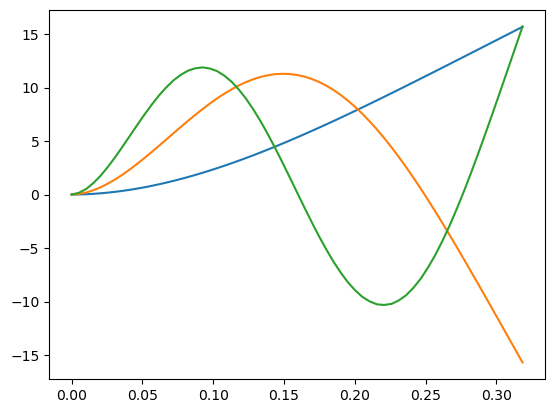

In [9]:
# %%
from IPython.display import clear_output
from matplotlib import cm, colors
import numpy as np
from numpy import pi
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import tqdm
L_b = 0.3185						# beam length [m]
w_p = 10e-3						# patch width [m]
w_s = 0.265625e-3					# spacing between patches [m]
Q = 31								# number of unit cells
S = Q								# one patch per cell
# positions

xL = np.array([(j-1)*w_p + j*w_s for j in range(1, S+1)], dtype=float)
xR = xL + w_p
eps0 = 8.854e-12
eps_r = 1900.0

d31 = -1.75e-10
s11 = 1.5873e-11; s44 = 4.75e-11
e31 = d31 / s11   
# print(f"e31ff = {e31:e} C/m^2")
eps33_bar = eps0 * eps_r
eps33 = eps33_bar - d31**2 / s11
# print(f"eps33_bar = {eps33_bar:e} F/m")

#  ===================== Beam material (6061 Al) =====================
rho_p, rho_s = 7600, 2700          # [kg/m³]
E_p, E_s   = 1/s11, 70e9           # [Pa]	
G_p = 1/s44; G_s = E_s / (2*(1+0.33))					# Pa
b = 10e-3						# m
hp, hs = 0.252e-3, 0.51e-3 					# m
hpc = (hp + hs)/2
#===================================Stiffness==========================
m = b*(rho_s * hs + 2 * rho_p * hp)
term1 = E_s * hs**3 / 8
term2 = E_p * ((hp + hs/2)**3 - hs**3/8)
YI = 2*b/3 * (term1 + term2)
# e31 = -14.76 #-5.4e-10						# C/m^2 (typical for PZT-5A)
# e31, eps33 = -14.76, 14.8e-9   

# A_term = (hp + 0.5*hs)**2 - (hs**2)/4.0
Cp_scalar = 2*eps33*  w_p * b / hp
Cp = Cp_scalar * np.ones(S)
theta_mech = 2*e31 * b *hpc		# parallel case (3.9)
xL = np.array([(j-1)*w_p + j*w_s for j in range(1, S+1)], dtype=float)
xR = xL + w_p
segments = []

# Initial gap
if xL[0] > 0:
    segments.append(("gap", 0.0, xL[0]))

# Patch-gap alternating sequence
for j in range(S):
    # Patch j
    segments.append(("patch", xL[j], xR[j]))

    # Gap after patch j (if not last)
    if j < S-1 and xR[j] < xL[j+1]:
        segments.append(("gap", xR[j], xL[j+1]))

# Final gap
if xR[-1] < L_b:
    segments.append(("gap", xR[-1], L_b))
n_el_patch = 2
n_el_gap   = 2
ks_patch = 0.9
ks_gap   = 0.9
x_nodes = [0.0]

for seg_type, xa, xb in segments:
    if seg_type == "patch":
        n = n_el_patch
    else:
        n = n_el_gap

    xs = np.linspace(xa, xb, n+1)

    # Skip first node to avoid duplication
    x_nodes.extend(xs[1:])
x_nodes = np.array(x_nodes)
Nnodes = len(x_nodes)
elements = [(i, i+1) for i in range(Nnodes-1)]
elem_type = []

for (i, j) in elements:
    xm = 0.5 * (x_nodes[i] + x_nodes[j])

    # Check if midpoint is inside any patch
    in_patch = any((xm >= xL[k]) and (xm <= xR[k]) for k in range(S))

    elem_type.append("patch" if in_patch else "gap")
rhoA_elem = []
EI_elem   = []
rhoA_patch = b * (rho_s * hs + 2 * rho_p * hp)
rhoA_gap   = b * rho_s * hs


EI_patch = YI
EI_gap   = E_s * b * hs**3 / 12

# rhoA_gap = rhoA_patch
# EI_gap = EI_patch

for t in elem_type:
    if t == "patch":
        rhoA_elem.append(rhoA_patch)
        EI_elem.append(EI_patch)

    else:
        rhoA_elem.append(rhoA_gap)
        EI_elem.append(EI_gap)
assert all(any(abs(x - xL[k]) < 1e-12 or abs(x - xR[k]) < 1e-12
               for k in range(S)) for x in x_nodes if x in np.concatenate((xL, xR)))
assert abs(x_nodes[-1] - L_b) < 1e-12
assert np.all(np.diff(x_nodes) > 0)

Ndof = 2 * Nnodes
K = np.zeros((Ndof, Ndof))

for e, (i, j) in enumerate(elements):

    Le = x_nodes[j] - x_nodes[i]
    EI = EI_elem[e]
    if elem_type[e] == "patch":
        ks = ks_patch
        G = (G_p * 2 * hp + G_s * hs) / (2 * hp + hs)
        A = b * (2 * hp + hs)
    else:
        A = b * hs
        G = G_s
        ks = ks_gap
    phi = 12*EI / (ks * A * G * Le**2)
    # print(f"Element type{elem_type[e]}: Le={Le:.4e}, EI={EI:.4e}, phi={phi:.4e}")
    Ke = (EI / (Le**3 * (1 + phi))) * np.array([
        [ 12,        6*Le,        -12,        6*Le ],
        [ 6*Le, (4+phi)*Le**2,  -6*Le, (2-phi)*Le**2 ],
        [ -12,       -6*Le,        12,       -6*Le ],
        [ 6*Le, (2-phi)*Le**2,  -6*Le, (4+phi)*Le**2 ]
    ])

    dofs = [
        2*i,     # w_i
        2*i + 1, # theta_i
        2*j,     # w_j
        2*j + 1  # theta_j
    ]

    # Assemble
    for a in range(4):
        for b in range(4):
            K[dofs[a], dofs[b]] += Ke[a, b]
M = np.zeros((Ndof, Ndof))

for e, (i, j) in enumerate(elements):

    Le = x_nodes[j] - x_nodes[i]
    rhoA = rhoA_elem[e]

    Me = (rhoA * Le / 420.0) * np.array([
        [156,       22*Le,     54,       -13*Le],
        [22*Le,   4*Le**2,   13*Le,    -3*Le**2],
        [54,        13*Le,    156,       -22*Le],
        [-13*Le, -3*Le**2,  -22*Le,     4*Le**2]
    ])

    dofs = [
        2*i,       # w_i
        2*i + 1,   # theta_i
        2*j,       # w_j
        2*j + 1    # theta_j
    ]

    for a in range(4):
        for b in range(4):
            M[dofs[a], dofs[b]] += Me[a, b]

fixed_dofs = [0, 1]  # w_0 = 0, theta_0 = 0

all_dofs = np.arange(Ndof)
free_dofs = np.setdiff1d(all_dofs, fixed_dofs)

K_full = K.copy()
M_full = M.copy()
K_full = K.copy()
M_full = M.copy()
K_red = K_full[np.ix_(free_dofs, free_dofs)]
M_red = M_full[np.ix_(free_dofs, free_dofs)]

assert np.linalg.norm(K - K.T) < 1e-10
eigvals = np.linalg.eigvalsh(K_red)
assert np.all(eigvals > 0)

from scipy.linalg import eigh

eigvals, eigvecs = eigh(K_red, M_red)
omega = np.sqrt(eigvals)        # rad/s
freq  = omega / (2*np.pi)       # Hz
idx = np.argsort(freq)
freq = freq[idx]
eigvecs = eigvecs[:, idx]
Nmodes = len(freq)
Phi = np.zeros((Ndof, Nmodes))

for i in range(Nmodes):
    Phi[free_dofs, i] = eigvecs[:, i]
for i in range(Nmodes):
    norm = np.sqrt(Phi[:, i].T @ M @ Phi[:, i])
    Phi[:, i] /= norm
print(freq[:5])
Phi.T @ M @ Phi   # ≈ identity
Phi.T @ K @ Phi   # ≈ diag(ω²)
w_dofs = np.arange(0, Ndof, 2)

for i in range(3):
    w_mode = Phi[w_dofs, i]
    plt.plot(x_nodes, w_mode, label=f"Mode {i+1}")



Eigenfrequency comparison (uniform beam)
Mode | f_COMSOL [Hz] | f_FE [Hz] | f_ROM [Hz]
------------------------------------------------
   1 |        5.3055 |    5.3193 |    5.6954
   2 |       33.2420 |   33.3351 |   35.6927
   3 |       93.0660 |   93.3321 |   99.9405
   4 |      182.3600 |  182.8808 |  195.8434
   5 |      301.4500 |  302.2956 |  323.7432
   6 |      450.3300 |  451.5510 |  483.6163
   7 |      629.0300 |  630.6466 |  675.4642
   8 |      837.5900 |  839.5818 |  899.2866
   9 |     1076.0000 | 1078.3575 | 1155.0837
  10 |     1344.4000 | 1346.9760 | 1442.8554
  11 |     1642.8000 | 1645.4411 | 1762.6017
  12 |     1971.1000 | 1973.7576 | 2114.3227
  13 |     2329.5000 | 2331.9310 | 2498.0183
  14 |     2717.8000 | 2719.9667 | 2913.6886
  15 |     3136.2000 | 3137.8689 | 3361.3335
  16 |     3584.5000 | 3585.6387 | 3840.9530
  17 |     4062.8000 | 4063.2715 | 4352.5472
  18 |     4570.8000 | 4570.7531 | 4896.1160
  19 |     5108.4000 | 5108.0530 | 5471.6594
  20 |  

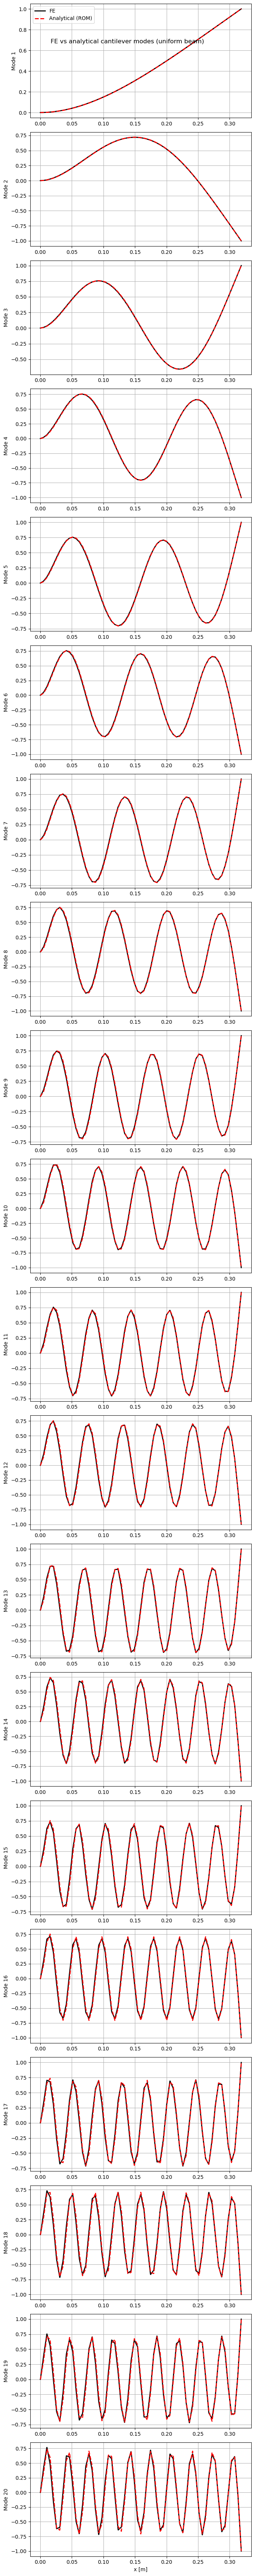


Modal Assurance Criterion (MAC)
Mode 1: MAC = 0.999997
Mode 2: MAC = 0.999972
Mode 3: MAC = 0.999906
Mode 4: MAC = 0.999791
Mode 5: MAC = 0.999620
Mode 6: MAC = 0.999389
Mode 7: MAC = 0.999091
Mode 8: MAC = 0.998720
Mode 9: MAC = 0.998270
Mode 10: MAC = 0.997734
Mode 11: MAC = 0.997105
Mode 12: MAC = 0.996378
Mode 13: MAC = 0.995544
Mode 14: MAC = 0.994598
Mode 15: MAC = 0.993531
Mode 16: MAC = 0.992334
Mode 17: MAC = 0.990999
Mode 18: MAC = 0.989513
Mode 19: MAC = 0.987864
Mode 20: MAC = 0.986033


In [10]:
# %%
import sys
from pathlib import Path

# --------------------------------------------------
# add project root to Python path
# --------------------------------------------------
project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

# --------------------------------------------------
# ROM imports (UPDATED)
# --------------------------------------------------
from Reduced_order.ROM import ROM
from beam_properties import PiezoBeamParams

# --------------------------------------------------
# standard imports
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FE vs analytical verification: mode shapes + eigenfrequencies
# ============================================================

# ----------------------------
# user settings
# ----------------------------
Nmodes_check = 20			# number of modes to compare
x_plot = x_nodes			# FE nodal coordinates
w_dofs = np.arange(0, Ndof, 2)		# transverse DOFs

# ----------------------------
# instantiate parameters + ROM
# ----------------------------
params = PiezoBeamParams()
rom = ROM(params, N=Nmodes_check)

# ----------------------------
# FE frequencies
# ----------------------------
f_fe = freq[:Nmodes_check]

# ----------------------------
# analytical frequencies (ROM-based)
# ----------------------------
omega_ana = rom.omega[:Nmodes_check]
f_ana = omega_ana / (2*np.pi)

# ----------------------------
# COMSOL reference frequencies
# ----------------------------
f_comsol = np.array([
	5.3055, 33.242, 93.066, 182.36, 301.45, 450.33, 629.03, 837.59,
	1076.0, 1344.4, 1642.8, 1971.1, 2329.5, 2717.8, 3136.2,
	3584.5, 4062.8, 4570.8, 5108.4, 5675.4, 6271.4, 6895.9, 7141.3
])

# ----------------------------
# frequency comparison table
# ----------------------------
print("\nEigenfrequency comparison (uniform beam)")
print("Mode | f_COMSOL [Hz] | f_FE [Hz] | f_ROM [Hz]")
print("------------------------------------------------")
for r in range(Nmodes_check):
	print(f"{r+1:4d} | {f_comsol[r]:13.4f} | {f_fe[r]:9.4f} | {f_ana[r]:9.4f}")

# ----------------------------
# mode shape comparison + MAC
# ----------------------------
MAC = np.zeros(Nmodes_check)

# consistent transverse mass matrix
Mw = M[np.ix_(w_dofs, w_dofs)]

plt.figure(figsize=(7, 3.5*Nmodes_check))

for r in range(Nmodes_check):

	# FE transverse mode
	w_fe = Phi[w_dofs, r].copy()

	# analytical transverse mode (ROM)
	w_ana = rom.mode_shape(r, x_plot)

	# sign consistency
	if np.dot(w_fe, w_ana) < 0.0:
		w_ana *= -1.0

	# normalize by max amplitude (visual comparison)
	w_fe /= np.max(np.abs(w_fe))
	w_ana /= np.max(np.abs(w_ana))

	# MAC computation
	num = np.abs(w_fe @ Mw @ w_ana)**2
	den = (w_fe @ Mw @ w_fe) * (w_ana @ Mw @ w_ana)
	MAC[r] = num / den

	# plot
	plt.subplot(Nmodes_check, 1, r+1)
	plt.plot(x_plot, w_fe, 'k-', lw=2, label='FE')
	plt.plot(x_plot, w_ana, 'r--', lw=2, label='Analytical (ROM)')
	plt.ylabel(f"Mode {r+1}")
	plt.grid(True)

	if r == 0:
		plt.legend()

plt.xlabel("x [m]")
plt.suptitle("FE vs analytical cantilever modes (uniform beam)", y=0.98)
plt.tight_layout()
plt.show()

# ----------------------------
# MAC summary
# ----------------------------
print("\nModal Assurance Criterion (MAC)")
for r in range(Nmodes_check):
	print(f"Mode {r+1}: MAC = {MAC[r]:.6f}")


In [11]:
G_s*1e-9

26.31578947368421